# Final Project Machine Learning

## Importing Libraries and Data

In [2]:
!pip install -q librosa soundfile

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from scipy.signal import find_peaks, welch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout,
    Conv2D, MaxPooling2D, Flatten,
    SimpleRNN, LSTM, GRU,
    InputLayer
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATA_DIR = "/content/drive/MyDrive/Training Data 2026"

# Quick check
print("Dataset folder exists:", os.path.exists(DATA_DIR))
print("Folder path:", DATA_DIR)

Dataset folder exists: True
Folder path: /content/drive/MyDrive/Training Data 2026


## Collect audio files and extract labels from file names

In [5]:
def parse_file_name(file_path):
    """
    Extract torque label, flange ID, and area ID from the file name.

    Expected file name examples:
        0ftlbF3A1.m4a
        25ftlbF2A3.m4a
        50ftlbF4A4.m4a

    Returns
    -------
    dict
        Metadata extracted from the file name.
    """

    file_name = os.path.basename(file_path)
    name_no_ext = os.path.splitext(file_name)[0]

    # Make matching easier by removing spaces and converting to lowercase
    clean_name = name_no_ext.replace(" ", "").lower()

    # Pattern explanation:
    # (0|25|50)ftlb  -> torque value
    # f(\d+)         -> flange number
    # a(\d+)         -> area number
    pattern = r"^(0|25|50)ftlbf(\d+)a(\d+)$"
    match = re.match(pattern, clean_name)

    if match is None:
        raise ValueError(f"File name does not match expected format: {file_name}")

    torque = int(match.group(1))
    flange_id = int(match.group(2))
    area_id = int(match.group(3))

    return {
        "file_name": file_name,
        "torque": torque,
        "flange_id": flange_id,
        "area_id": area_id
    }


def collect_audio_files(data_dir):
    """
    Search the dataset folder and collect all audio files.

    This function accepts .m4a and .wav because the current project data
    appears to be stored as .m4a files, while our previous homework used .wav.
    """

    audio_extensions = ["*.m4a", "*.wav", "*.mp3"]
    file_paths = []

    for ext in audio_extensions:
        file_paths.extend(glob.glob(os.path.join(data_dir, ext)))

    rows = []

    for file_path in sorted(file_paths):
        try:
            info = parse_file_name(file_path)
            info["file_path"] = file_path
            rows.append(info)

        except ValueError as e:
            print("Skipped:", file_path)
            print("Reason:", e)

    return pd.DataFrame(rows)


files_df = collect_audio_files(DATA_DIR)

print("Number of audio files found:", len(files_df))
display(files_df.head())

Number of audio files found: 48


,file_name,torque,flange_id,area_id,file_path
0,0ftlbF1A1.m4a,0,1,1,/content/drive/MyDrive/Training Data 2026/0ftl...
1,0ftlbF1A2.m4a,0,1,2,/content/drive/MyDrive/Training Data 2026/0ftl...
2,0ftlbF1A3.m4a,0,1,3,/content/drive/MyDrive/Training Data 2026/0ftl...
3,0ftlbF1A4.m4a,0,1,4,/content/drive/MyDrive/Training Data 2026/0ftl...
4,0ftlbF2A1.m4a,0,2,1,/content/drive/MyDrive/Training Data 2026/0ftl...


### Basic dataset summary

In [6]:
print("Files per torque class:")
display(files_df["torque"].value_counts().sort_index())

print("\nFiles per flange:")
display(files_df["flange_id"].value_counts().sort_index())

print("\nFiles per area:")
display(files_df["area_id"].value_counts().sort_index())

print("\nDetailed count by torque and flange:")
display(pd.crosstab(files_df["torque"], files_df["flange_id"]))

Files per torque class:


,count
torque,
0,16
25,16
50,16



Files per flange:


,count
flange_id,
1,12
2,12
3,12
4,12



Files per area:


,count
area_id,
1,12
2,12
3,12
4,12



Detailed count by torque and flange:


flange_id,1,2,3,4
torque,,,,
0,4,4,4,4
25,4,4,4,4
50,4,4,4,4


## EDA and data preprocessing

### Visualize file distribution

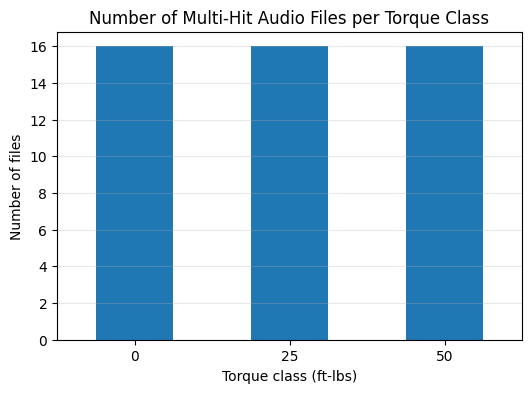

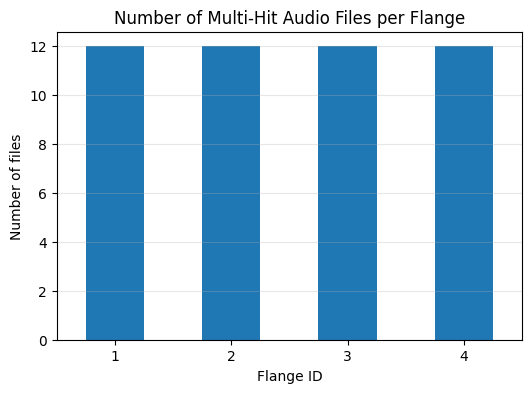

In [7]:
plt.figure(figsize=(6, 4))
files_df["torque"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Multi-Hit Audio Files per Torque Class")
plt.xlabel("Torque class (ft-lbs)")
plt.ylabel("Number of files")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
files_df["flange_id"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Multi-Hit Audio Files per Flange")
plt.xlabel("Flange ID")
plt.ylabel("Number of files")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

### Load one audio file and inspect it

/tmp/ipykernel_8894/2228987257.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(example_path, sr=None, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Example file: 0ftlbF1A1.m4a
Sampling rate: 48000
Signal duration: 17.17 seconds
Signal shape: (824256,)


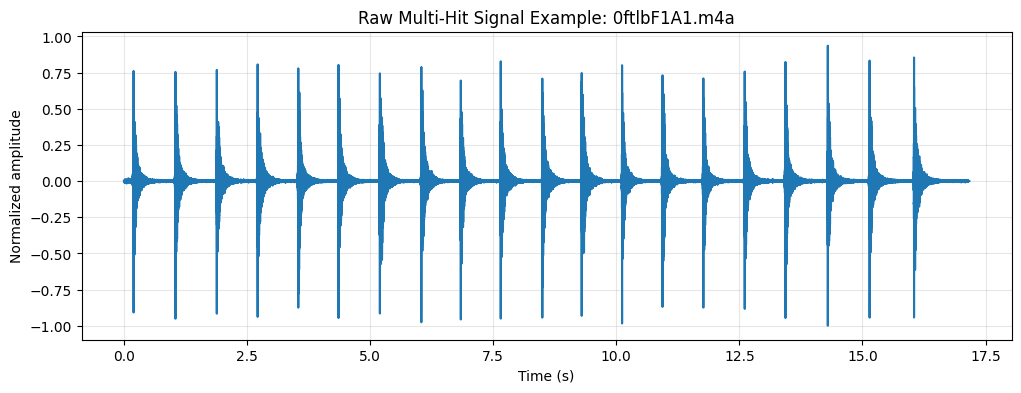

In [8]:
example_path = files_df.iloc[0]["file_path"]
example_name = files_df.iloc[0]["file_name"]

# sr=None keeps the original sampling rate, which should be around 48 kHz
signal, sr = librosa.load(example_path, sr=None, mono=True)

# Normalize amplitude for easier visualization
signal = signal / np.max(np.abs(signal))

time_axis = np.arange(len(signal)) / sr

print("Example file:", example_name)
print("Sampling rate:", sr)
print("Signal duration:", round(len(signal) / sr, 2), "seconds")
print("Signal shape:", signal.shape)

plt.figure(figsize=(12, 4))
plt.plot(time_axis, signal)
plt.title(f"Raw Multi-Hit Signal Example: {example_name}")
plt.xlabel("Time (s)")
plt.ylabel("Normalized amplitude")
plt.grid(alpha=0.3)
plt.show()

# Single-hit segmentation

In [9]:
IGNORE_START_SEC = 0.15      # ignore the first part to avoid recording/touch noise
ENVELOPE_WIN_SEC = 0.01      # smoothing window for the envelope
MIN_PEAK_DISTANCE_SEC = 0.30 # minimum time between two hits
PEAK_HEIGHT_FACTOR = 2.5     # threshold = mean + factor * std
PRE_HIT_SEC = 0.02           # keep a little signal before the impact
POST_HIT_SEC = 0.15         # keep the impact decay after the peak

In [10]:
def normalize_audio(signal):
    """
    Normalize the audio signal between -1 and 1.
    This makes the segmentation less sensitive to recording volume.
    """
    max_value = np.max(np.abs(signal))

    if max_value == 0:
        return signal

    return signal / max_value


def split_into_hits(signal, sr):
    """
    Split a multi-hit audio signal into separate single-hit signals.

    Parameters
    ----------
    signal : numpy.ndarray
        Full audio signal.
    sr : int
        Sampling rate.

    Returns
    -------
    hits : list
        List of single-hit audio segments.
    peaks : numpy.ndarray
        Peak locations detected in the trimmed signal.
    envelope : numpy.ndarray
        Smoothed envelope used for peak detection.
    signal_trimmed : numpy.ndarray
        Signal after ignoring the starting part.
    """

    # Remove the very beginning of the recording
    start_idx = int(IGNORE_START_SEC * sr)
    signal_trimmed = signal[start_idx:]

    # Build a smooth amplitude envelope
    envelope_win = max(1, int(ENVELOPE_WIN_SEC * sr))
    kernel = np.ones(envelope_win) / envelope_win
    envelope = np.convolve(np.abs(signal_trimmed), kernel, mode="same")

    # Peak detection threshold
    threshold = np.mean(envelope) + PEAK_HEIGHT_FACTOR * np.std(envelope)

    # Minimum spacing between hits
    min_distance = int(MIN_PEAK_DISTANCE_SEC * sr)

    peaks, properties = find_peaks(
        envelope,
        height=threshold,
        distance=min_distance
    )

    # Cut a fixed window around each detected impact
    pre_samples = int(PRE_HIT_SEC * sr)
    post_samples = int(POST_HIT_SEC * sr)

    hits = []

    for peak in peaks:
        start = max(0, peak - pre_samples)
        end = min(len(signal_trimmed), peak + post_samples)

        hit = signal_trimmed[start:end]

        if len(hit) > 0:
            hits.append(hit)

    return hits, peaks, envelope, signal_trimmed

## Test hit segmentation on one example file

/tmp/ipykernel_8894/2499635976.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(example_path, sr=None, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Example file: 0ftlbF1A1.m4a
Sampling rate: 48000
Number of detected hits: 20


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


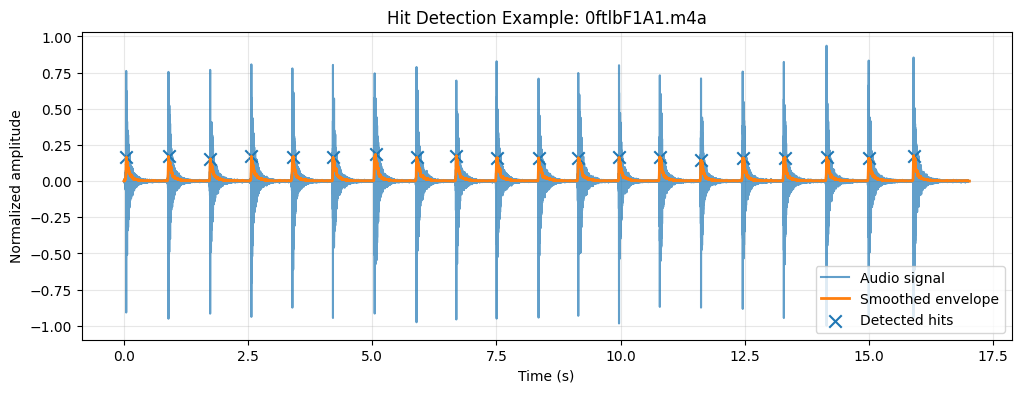

In [11]:
example_path = files_df.iloc[0]["file_path"]
example_name = files_df.iloc[0]["file_name"]

# Load audio
signal, sr = librosa.load(example_path, sr=None, mono=True)
signal = normalize_audio(signal)

# Split into hits
hits, peaks, envelope, signal_trimmed = split_into_hits(signal, sr)

print("Example file:", example_name)
print("Sampling rate:", sr)
print("Number of detected hits:", len(hits))

# Time axis after trimming
time_trimmed = np.arange(len(signal_trimmed)) / sr

plt.figure(figsize=(12, 4))
plt.plot(time_trimmed, signal_trimmed, label="Audio signal", alpha=0.7)
plt.plot(time_trimmed, envelope, label="Smoothed envelope", linewidth=2)
plt.scatter(peaks / sr, envelope[peaks], marker="x", s=80, label="Detected hits")

plt.title(f"Hit Detection Example: {example_name}")
plt.xlabel("Time (s)")
plt.ylabel("Normalized amplitude")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Visualize some extracted single-hit signals

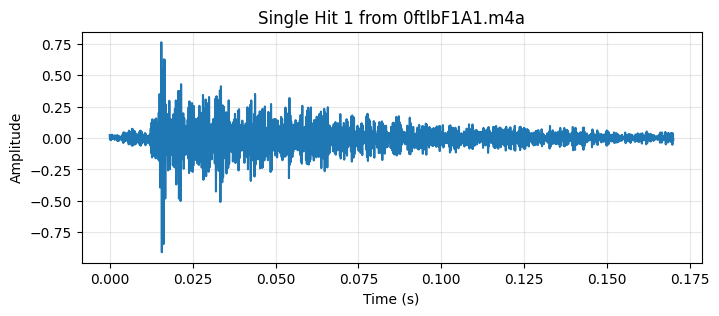

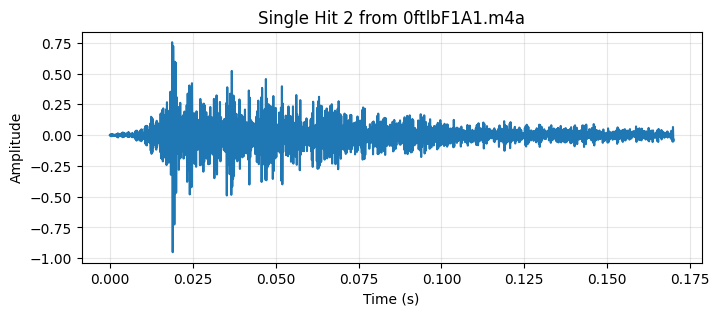

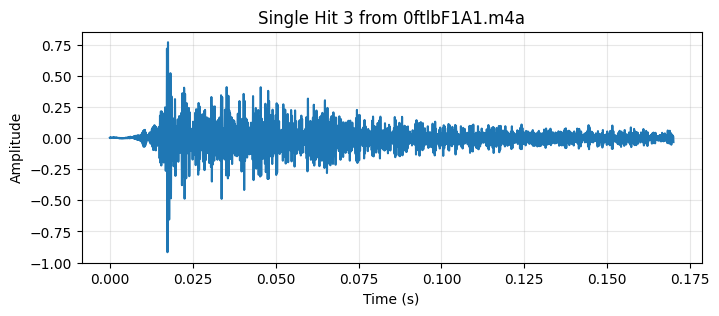

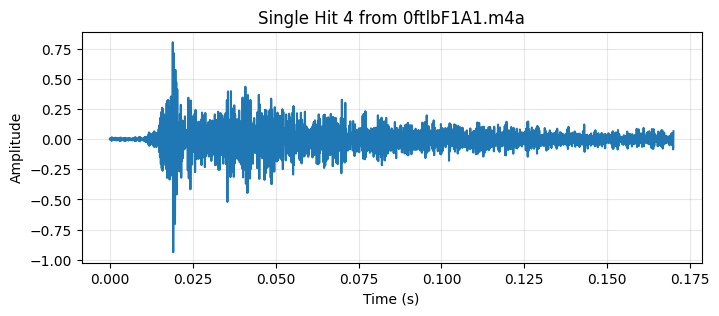

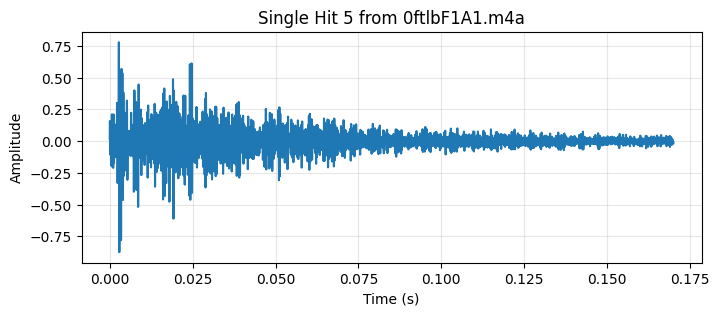

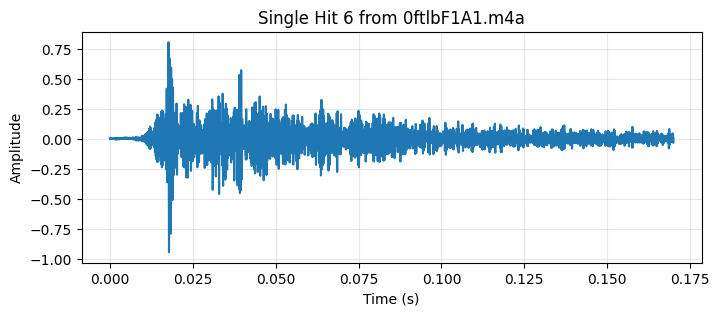

In [12]:
num_hits_to_plot = min(6, len(hits))

for i in range(num_hits_to_plot):
    hit = hits[i]
    hit_time = np.arange(len(hit)) / sr

    plt.figure(figsize=(8, 3))
    plt.plot(hit_time, hit)
    plt.title(f"Single Hit {i + 1} from {example_name}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(alpha=0.3)
    plt.show()

##Build the complete single-hit dataset

In [13]:
def build_hit_dataset(files_df):
    """
    Convert all multi-hit audio files into individual single-hit samples.

    Each detected hit becomes one training sample.

    Returns
    -------
    hits_list : list of dict
        Each dictionary contains:
        - signal
        - sampling rate
        - torque label
        - flange ID
        - area ID
        - source file name
    """

    hits_list = []

    for _, row in files_df.iterrows():
        file_path = row["file_path"]

        # Load and normalize the audio
        signal, sr = librosa.load(file_path, sr=None, mono=True)
        signal = normalize_audio(signal)

        # Split the recording into individual hits
        hit_segments, _, _, _ = split_into_hits(signal, sr)

        # Store each hit as one sample
        for hit_id, hit_signal in enumerate(hit_segments, start=1):
            hits_list.append({
                "file_name": row["file_name"],
                "file_path": file_path,
                "hit_id": hit_id,
                "torque": row["torque"],
                "flange_id": row["flange_id"],
                "area_id": row["area_id"],
                "sr": sr,
                "signal": hit_signal
            })

    return hits_list


hits_data = build_hit_dataset(files_df)

print("Total number of single-hit samples:", len(hits_data))

# Create a light summary dataframe without storing the full signal
hits_summary_df = pd.DataFrame([
    {
        "file_name": item["file_name"],
        "hit_id": item["hit_id"],
        "torque": item["torque"],
        "flange_id": item["flange_id"],
        "area_id": item["area_id"],
        "sr": item["sr"],
        "hit_length_samples": len(item["signal"]),
        "hit_duration_sec": len(item["signal"]) / item["sr"]
    }
    for item in hits_data
])

display(hits_summary_df.head())

/tmp/ipykernel_8894/770258947.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, sr=None, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_8894/770258947.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, sr=None, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_8894/770258947.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, sr=None, mono=Tru

Total number of single-hit samples: 987


,file_name,hit_id,torque,flange_id,area_id,sr,hit_length_samples,hit_duration_sec
0,0ftlbF1A1.m4a,1,0,1,1,48000,8160,0.17
1,0ftlbF1A1.m4a,2,0,1,1,48000,8160,0.17
2,0ftlbF1A1.m4a,3,0,1,1,48000,8160,0.17
3,0ftlbF1A1.m4a,4,0,1,1,48000,8160,0.17
4,0ftlbF1A1.m4a,5,0,1,1,48000,8160,0.17


### Check how many single-hit samples we have per class

In [14]:
print("Single-hit samples per torque class:")
display(hits_summary_df["torque"].value_counts().sort_index())

print("\nSingle-hit samples per flange:")
display(hits_summary_df["flange_id"].value_counts().sort_index())

print("\nSingle-hit samples by torque and flange:")
display(pd.crosstab(hits_summary_df["torque"], hits_summary_df["flange_id"]))

print("\nSingle-hit samples by torque and area:")
display(pd.crosstab(hits_summary_df["torque"], hits_summary_df["area_id"]))

Single-hit samples per torque class:


,count
torque,
0,328
25,328
50,331



Single-hit samples per flange:


,count
flange_id,
1,246
2,243
3,251
4,247



Single-hit samples by torque and flange:


flange_id,1,2,3,4
torque,,,,
0,80,81,84,83
25,82,80,86,80
50,84,82,81,84



Single-hit samples by torque and area:


area_id,1,2,3,4
torque,,,,
0,82,83,82,81
25,82,84,81,81
50,80,88,83,80


### Plot distribution of detected single hits

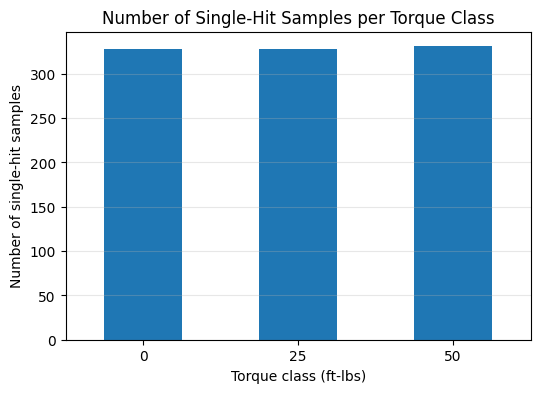

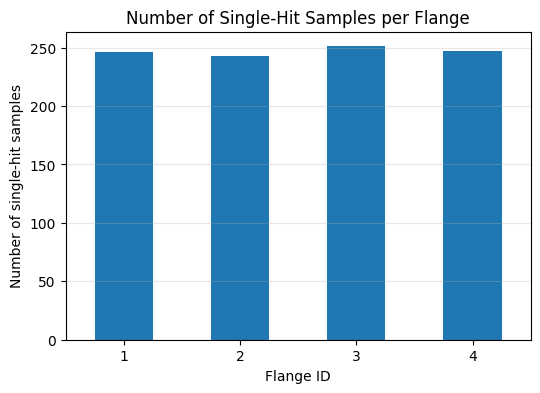

In [15]:
plt.figure(figsize=(6, 4))
hits_summary_df["torque"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Single-Hit Samples per Torque Class")
plt.xlabel("Torque class (ft-lbs)")
plt.ylabel("Number of single-hit samples")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
hits_summary_df["flange_id"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Single-Hit Samples per Flange")
plt.xlabel("Flange ID")
plt.ylabel("Number of single-hit samples")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Feature extraction functions

In [16]:
N_MFCC = 13          # number of MFCC coefficients for classical models
N_FFT = 2048         # FFT window size
HOP_LENGTH = 512     # hop length for MFCC
N_PSD_BINS = 128     # fixed number of PSD values kept


In [32]:
def safe_mean_std(feature_matrix):
    """
    Convert a time-varying feature into mean and standard deviation.

    This keeps the feature vector fixed-size while still preserving
    the average behavior and variability over time.
    """
    feature_matrix = np.asarray(feature_matrix)

    mean_values = np.mean(feature_matrix, axis=1)
    std_values = np.std(feature_matrix, axis=1)

    return np.concatenate([mean_values, std_values])


def extract_psd_features(signal, sr, n_bins=N_PSD_BINS):
    """
    Extract fixed-length log-PSD features using Welch's method.

    PSD tells us how the impact energy is distributed over frequency.
    """
    freqs, psd = welch(
        signal,
        fs=sr,
        nperseg=min(1024, len(signal))
    )

    psd_log = np.log10(psd + 1e-12)

    if len(psd_log) >= n_bins:
        psd_features = psd_log[:n_bins]
    else:
        psd_features = np.pad(
            psd_log,
            (0, n_bins - len(psd_log)),
            mode="constant"
        )

    return psd_features


def extract_mfcc_features(signal, sr):
    """
    Extract MFCC mean/std and delta MFCC mean/std.

    MFCC captures the sound texture.
    Delta MFCC captures how the sound changes over time.
    """
    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=min(N_FFT, len(signal)),
        hop_length=min(HOP_LENGTH, max(1, len(signal) // 2))
    )

    mfcc_delta = librosa.feature.delta(mfcc)

    mfcc_features = safe_mean_std(mfcc)
    delta_features = safe_mean_std(mfcc_delta)

    return np.concatenate([mfcc_features, delta_features])


def extract_spectral_summary_features(signal, sr):
    """
    Extract compact spectral and energy features.

    These describe the brightness, spread, noisiness, and energy
    behavior of each percussion hit.
    """
    n_fft = min(N_FFT, len(signal))
    hop_length = min(HOP_LENGTH, max(1, len(signal) // 2))

    centroid = librosa.feature.spectral_centroid(
        y=signal,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length
    )

    bandwidth = librosa.feature.spectral_bandwidth(
        y=signal,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length
    )

    rolloff = librosa.feature.spectral_rolloff(
        y=signal,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        roll_percent=0.85
    )

    flatness = librosa.feature.spectral_flatness(
        y=signal,
        n_fft=n_fft,
        hop_length=hop_length
    )

    zcr = librosa.feature.zero_crossing_rate(
        y=signal,
        frame_length=n_fft,
        hop_length=hop_length
    )

    rms = librosa.feature.rms(
        y=signal,
        frame_length=n_fft,
        hop_length=hop_length
    )

    features = np.concatenate([
        safe_mean_std(centroid),
        safe_mean_std(bandwidth),
        safe_mean_std(rolloff),
        safe_mean_std(flatness),
        safe_mean_std(zcr),
        safe_mean_std(rms)
    ])

    return features


def extract_frequency_shape_features(signal, sr):
    """
    Extract dominant frequency and spectral entropy.

    Dominant frequency can shift when the flange condition changes.
    Spectral entropy measures how spread or concentrated the spectrum is.
    """
    freqs, psd = welch(
        signal,
        fs=sr,
        nperseg=min(1024, len(signal))
    )

    psd = psd + 1e-12

    dominant_freq = freqs[np.argmax(psd)]

    psd_norm = psd / np.sum(psd)
    spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))

    return np.array([dominant_freq, spectral_entropy])


def extract_decay_features(signal, sr):
    """
    Extract simple time-domain decay features.

    For percussion sounds, the way the signal rings and decays can carry
    information about looseness/tightness.
    """
    abs_signal = np.abs(signal)

    if np.max(abs_signal) == 0:
        return np.zeros(5)

    # Smooth the envelope slightly
    win = max(1, int(0.002 * sr))
    kernel = np.ones(win) / win
    envelope = np.convolve(abs_signal, kernel, mode="same")

    peak_idx = np.argmax(envelope)
    peak_value = envelope[peak_idx] + 1e-12

    after_peak = envelope[peak_idx:]

    # Time to decay below 50% and 10% of peak
    below_50 = np.where(after_peak <= 0.50 * peak_value)[0]
    below_10 = np.where(after_peak <= 0.10 * peak_value)[0]

    decay_50_time = below_50[0] / sr if len(below_50) > 0 else len(after_peak) / sr
    decay_10_time = below_10[0] / sr if len(below_10) > 0 else len(after_peak) / sr

    # Log-envelope decay slope
    time_after_peak = np.arange(len(after_peak)) / sr
    log_env = np.log(after_peak + 1e-8)

    if len(time_after_peak) > 5:
        slope = np.polyfit(time_after_peak, log_env, 1)[0]
    else:
        slope = 0.0

    total_energy = np.sum(signal ** 2)
    peak_time = peak_idx / sr

    return np.array([
        peak_value,
        peak_time,
        decay_50_time,
        decay_10_time,
        slope
    ])


def extract_hybrid_features(signal, sr):
    """
    Final improved feature vector for shallow models.

    This replaces the old PSD + MFCC-only feature vector.
    """
    psd_features = extract_psd_features(signal, sr)
    mfcc_features = extract_mfcc_features(signal, sr)
    spectral_features = extract_spectral_summary_features(signal, sr)
    frequency_shape_features = extract_frequency_shape_features(signal, sr)
    decay_features = extract_decay_features(signal, sr)

    final_features = np.concatenate([
        psd_features,
        mfcc_features,
        spectral_features,
        frequency_shape_features,
        decay_features
    ])

    return final_features



# Shallow Learning Models
In this section, we build the final engineered feature matrix and evaluate the shallow learning models.

The models tested are:

- Logistic Regression
- SVM
- Random Forest
- Gradient Boosting
- Two-Stage Logistic Regression
- Two-Stage SVM
- Two-Stage Random Forest

The main feature matrix is built from the improved hybrid audio features extracted from each single-hit signal.

In [46]:
# ============================================================
# Build feature matrix for shallow learning models
# ============================================================
# Each single hit becomes one row in X_features.
# The label is the torque value: 0, 25, or 50 ft-lbs.
#
# These features will be used by:
#   Logistic Regression
#   SVM
#   Random Forest
#   Gradient Boosting
#   Two-Stage models

X_features = []
y_labels = []
flange_ids = []
area_ids = []
source_files = []

for item in hits_data:
    features = extract_hybrid_features(item["signal"], item["sr"])

    X_features.append(features)
    y_labels.append(item["torque"])
    flange_ids.append(item["flange_id"])
    area_ids.append(item["area_id"])
    source_files.append(item["file_name"])

X_features = np.array(X_features)
y_labels = np.array(y_labels)
flange_ids = np.array(flange_ids)
area_ids = np.array(area_ids)
source_files = np.array(source_files)

print("Feature matrix shape:", X_features.shape)
print("Label vector shape:", y_labels.shape)
print("Flange ID shape:", flange_ids.shape)
print("Classes:", np.unique(y_labels))

Feature matrix shape: (987, 223)
Label vector shape: (987,)
Flange ID shape: (987,)
Classes: [ 0 25 50]


In [47]:
# ============================================================
# Quick check of the feature dataset
# ============================================================

CLASS_NAMES = ["0 ft-lbs", "25 ft-lbs", "50 ft-lbs"]

print("Samples per torque class:")
display(pd.Series(y_labels).value_counts().sort_index())

print("\nSamples per flange:")
display(pd.Series(flange_ids).value_counts().sort_index())

print("\nSamples by torque and flange:")
display(pd.crosstab(y_labels, flange_ids))

Samples per torque class:


,count
0,328
25,328
50,331



Samples per flange:


,count
1,246
2,243
3,251
4,247



Samples by torque and flange:


col_0,1,2,3,4
row_0,,,,
0,80,81,84,83
25,82,80,86,80
50,84,82,81,84


In [48]:
# ============================================================
# Regular model builders
# ============================================================
# These functions return fresh models every time they are called.
# This is important for independent testing because each held-out flange
# should get a newly trained model.

def make_logistic_regression():
    """
    Logistic Regression with feature scaling.

    Scaling is needed because Logistic Regression is sensitive to feature scale.
    """
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            solver="lbfgs",
            random_state=RANDOM_STATE
        ))
    ])


def make_svm():
    """
    SVM with RBF kernel and feature scaling.

    The RBF kernel helps when the classes are not linearly separated.
    """
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ])


def make_random_forest():
    """
    Random Forest model.

    Random Forest does not require feature scaling.
    This model has been one of the strongest performers so far.
    """
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


def make_gradient_boosting():
    """
    Gradient Boosting model.

    It can capture nonlinear feature interactions, but it was less stable
    than Random Forest in our previous tests.
    """
    return GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )


def get_regular_models():
    """
    Return all regular shallow models in one dictionary.
    """
    return {
        "Logistic Regression": make_logistic_regression(),
        "SVM": make_svm(),
        "Random Forest": make_random_forest(),
        "Gradient Boosting": make_gradient_boosting()
    }

In [49]:
# ============================================================
# Dependent Test: 70:30 split
# ============================================================

X_train_dep, X_test_dep, y_train_dep, y_test_dep = train_test_split(
    X_features,
    y_labels,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_labels
)

dependent_results = []
dependent_predictions = {}

regular_models = get_regular_models()

for model_name, model in regular_models.items():

    print("=" * 70)
    print(f"Training {model_name} on dependent split")
    print("=" * 70)

    model.fit(X_train_dep, y_train_dep)
    y_pred_dep = model.predict(X_test_dep)

    acc_dep = accuracy_score(y_test_dep, y_pred_dep)

    dependent_results.append({
        "Model": model_name,
        "Dependent Accuracy (%)": acc_dep * 100
    })

    dependent_predictions[model_name] = y_pred_dep

    print(f"{model_name} Dependent Accuracy: {acc_dep * 100:.2f}%")
    print(classification_report(
        y_test_dep,
        y_pred_dep,
        target_names=CLASS_NAMES,
        zero_division=0
    ))

dependent_results_df = pd.DataFrame(dependent_results).sort_values(
    by="Dependent Accuracy (%)",
    ascending=False
).reset_index(drop=True)

display(dependent_results_df)

Training Logistic Regression on dependent split
Logistic Regression Dependent Accuracy: 100.00%
              precision    recall  f1-score   support

    0 ft-lbs       1.00      1.00      1.00        99
   25 ft-lbs       1.00      1.00      1.00        99
   50 ft-lbs       1.00      1.00      1.00        99

    accuracy                           1.00       297
   macro avg       1.00      1.00      1.00       297
weighted avg       1.00      1.00      1.00       297

Training SVM on dependent split
SVM Dependent Accuracy: 99.66%
              precision    recall  f1-score   support

    0 ft-lbs       0.99      1.00      0.99        99
   25 ft-lbs       1.00      0.99      0.99        99
   50 ft-lbs       1.00      1.00      1.00        99

    accuracy                           1.00       297
   macro avg       1.00      1.00      1.00       297
weighted avg       1.00      1.00      1.00       297

Training Random Forest on dependent split
Random Forest Dependent Accuracy: 99.

,Model,Dependent Accuracy (%)
0,Logistic Regression,100.0000
1,Gradient Boosting,100.0000
2,SVM,99.6633
3,Random Forest,99.6633


In [50]:
# ============================================================
# Two-stage classification helper functions
# ============================================================

def convert_to_binary_loose(y):
    """
    Convert torque labels into binary labels.

    0  -> 0  meaning tight / no looseness
    25 -> 1  meaning loose
    50 -> 1  meaning loose
    """
    return np.where(y == 0, 0, 1)


def make_model_by_name(model_name):
    """
    Create a fresh regular model based on a short model name.
    """
    if model_name == "LR":
        return make_logistic_regression()

    if model_name == "SVM":
        return make_svm()

    if model_name == "RF":
        return make_random_forest()

    raise ValueError("model_name must be 'LR', 'SVM', or 'RF'.")


def make_tuned_rf_stage2():
    """
    Tuned Random Forest for Stage 2.

    Stage 2 separates 25 ft-lbs from 50 ft-lbs.
    From our tuning, the best setting was:
        max_depth = 12
        min_samples_leaf = 3
    """
    return RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


def train_two_stage_model(X_train, y_train, base_model_name="RF"):
    """
    Train a two-stage model.

    Stage 1:
        0 ft-lbs vs loose

    Stage 2:
        25 ft-lbs vs 50 ft-lbs

    For RF, Stage 2 uses the tuned RF parameters found during testing.
    """

    # ----------------------------
    # Stage 1: 0 vs loose
    # ----------------------------
    stage1_model = make_model_by_name(base_model_name)

    y_train_stage1 = convert_to_binary_loose(y_train)
    stage1_model.fit(X_train, y_train_stage1)

    # ----------------------------
    # Stage 2: 25 vs 50 only
    # ----------------------------
    loose_mask = y_train != 0

    X_train_stage2 = X_train[loose_mask]
    y_train_stage2 = y_train[loose_mask]

    # Use tuned RF only for RF Stage 2
    if base_model_name == "RF":
        stage2_model = make_tuned_rf_stage2()
    else:
        stage2_model = make_model_by_name(base_model_name)

    stage2_model.fit(X_train_stage2, y_train_stage2)

    return stage1_model, stage2_model


def predict_two_stage(stage1_model, stage2_model, X_test):
    """
    Predict final torque labels using a trained two-stage model.

    If Stage 1 predicts 0, the final prediction is 0.
    If Stage 1 predicts loose, Stage 2 chooses between 25 and 50.
    """

    stage1_pred = stage1_model.predict(X_test)

    final_pred = np.zeros(len(X_test), dtype=int)

    loose_mask = stage1_pred == 1

    if np.sum(loose_mask) > 0:
        final_pred[loose_mask] = stage2_model.predict(X_test[loose_mask])

    return final_pred

In [51]:
# ============================================================
# Dependent Test: Two-stage models
# ============================================================

two_stage_dependent_results = []

for model_type in ["RF", "SVM", "LR"]:

    stage1_model, stage2_model = train_two_stage_model(
        X_train=X_train_dep,
        y_train=y_train_dep,
        base_model_name=model_type
    )

    y_pred_two_stage_dep = predict_two_stage(
        stage1_model=stage1_model,
        stage2_model=stage2_model,
        X_test=X_test_dep
    )

    acc_dep = accuracy_score(y_test_dep, y_pred_two_stage_dep)

    two_stage_dependent_results.append({
        "Model": f"Two-Stage {model_type}",
        "Dependent Accuracy (%)": acc_dep * 100
    })

two_stage_dependent_results_df = pd.DataFrame(two_stage_dependent_results)

dependent_all_results_df = pd.concat(
    [dependent_results_df, two_stage_dependent_results_df],
    ignore_index=True
).sort_values(
    by="Dependent Accuracy (%)",
    ascending=False
).reset_index(drop=True)

display(dependent_all_results_df)

,Model,Dependent Accuracy (%)
0,Logistic Regression,100.000000
1,Gradient Boosting,100.000000
2,Two-Stage LR,100.000000
3,SVM,99.663300
4,Random Forest,99.663300
5,Two-Stage RF,99.663300
6,Two-Stage SVM,99.326599


In [ ]:
# ============================================================
# Independent Test: Regular models
# ============================================================

independent_regular_results = []

for test_flange in [1, 2, 3, 4]:

    print("=" * 70)
    print(f"Independent Test: Held-out Flange {test_flange}")
    print("=" * 70)

    train_mask = flange_ids != test_flange
    test_mask = flange_ids == test_flange

    X_train_ind = X_features[train_mask]
    X_test_ind = X_features[test_mask]

    y_train_ind = y_labels[train_mask]
    y_test_ind = y_labels[test_mask]

    regular_models = get_regular_models()

    for model_name, model in regular_models.items():

        model.fit(X_train_ind, y_train_ind)
        y_pred_ind = model.predict(X_test_ind)

        acc_ind = accuracy_score(y_test_ind, y_pred_ind)

        independent_regular_results.append({
            "Model": model_name,
            "Test Flange": test_flange,
            "Accuracy (%)": acc_ind * 100
        })

        print(f"{model_name}: {acc_ind * 100:.2f}%")

independent_regular_results_df = pd.DataFrame(independent_regular_results)

display(independent_regular_results_df)

Independent Test: Held-out Flange 1
Logistic Regression: 60.16%
SVM: 56.91%
Random Forest: 57.72%
Gradient Boosting: 50.41%
Independent Test: Held-out Flange 2
Logistic Regression: 72.84%
SVM: 71.19%
Random Forest: 76.95%


In [ ]:
# ============================================================
# Independent Test: Two-stage models
# ============================================================

independent_two_stage_results = []

for test_flange in [1, 2, 3, 4]:

    print("=" * 70)
    print(f"Two-Stage Independent Test: Held-out Flange {test_flange}")
    print("=" * 70)

    train_mask = flange_ids != test_flange
    test_mask = flange_ids == test_flange

    X_train_ind = X_features[train_mask]
    X_test_ind = X_features[test_mask]

    y_train_ind = y_labels[train_mask]
    y_test_ind = y_labels[test_mask]

    for model_type in ["RF", "SVM", "LR"]:

        stage1_model, stage2_model = train_two_stage_model(
            X_train=X_train_ind,
            y_train=y_train_ind,
            base_model_name=model_type
        )

        y_pred_two_stage = predict_two_stage(
            stage1_model=stage1_model,
            stage2_model=stage2_model,
            X_test=X_test_ind
        )

        acc_two_stage = accuracy_score(y_test_ind, y_pred_two_stage)

        independent_two_stage_results.append({
            "Model": f"Two-Stage {model_type}",
            "Test Flange": test_flange,
            "Accuracy (%)": acc_two_stage * 100
        })

        print(f"Two-Stage {model_type}: {acc_two_stage * 100:.2f}%")

independent_two_stage_results_df = pd.DataFrame(independent_two_stage_results)

display(independent_two_stage_results_df)

In [ ]:
# ============================================================
# Combine independent hit-level results
# ============================================================

independent_results_df = pd.concat(
    [
        independent_regular_results_df,
        independent_two_stage_results_df
    ],
    ignore_index=True
)

display(independent_results_df)

independent_average_df = (
    independent_results_df
    .groupby("Model")["Accuracy (%)"]
    .mean()
    .reset_index()
    .sort_values(by="Accuracy (%)", ascending=False)
)

print("Average Independent Hit-Level Accuracy:")
display(independent_average_df)

plt.figure(figsize=(10, 5))
plt.bar(
    independent_average_df["Model"],
    independent_average_df["Accuracy (%)"]
)
plt.title("Average Independent Hit-Level Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
# ============================================================
# Best model per held-out flange
# ============================================================

flange_model_accuracy = independent_results_df.pivot_table(
    index="Test Flange",
    columns="Model",
    values="Accuracy (%)",
    aggfunc="mean"
)

flange_model_accuracy = flange_model_accuracy.sort_index()

accuracy_columns = flange_model_accuracy.columns

flange_model_accuracy["Best Model"] = flange_model_accuracy[accuracy_columns].idxmax(axis=1)
flange_model_accuracy["Best Accuracy (%)"] = flange_model_accuracy[accuracy_columns].max(axis=1)

styled_flange_table = (
    flange_model_accuracy
    .style
    .format(precision=2)
    .highlight_max(
        axis=1,
        subset=accuracy_columns,
        color="lightgreen"
    )
    .set_caption("Independent Hit-Level Accuracy by Held-Out Flange")
)

display(styled_flange_table)

In [ ]:
# ============================================================
# File-level majority voting helper functions
# ============================================================

def majority_vote(series):
    """
    Return the most common value in a pandas Series.
    """
    return series.value_counts().idxmax()


def evaluate_file_level_regular(model_name, model):
    """
    Evaluate a regular model using file-level majority voting.
    """

    file_level_results = []

    for test_flange in [1, 2, 3, 4]:

        train_mask = flange_ids != test_flange
        test_mask = flange_ids == test_flange

        X_train_ind = X_features[train_mask]
        X_test_ind = X_features[test_mask]

        y_train_ind = y_labels[train_mask]
        y_test_ind = y_labels[test_mask]

        test_files = source_files[test_mask]

        model.fit(X_train_ind, y_train_ind)
        y_pred_hit = model.predict(X_test_ind)

        temp_df = pd.DataFrame({
            "file_name": test_files,
            "true_label": y_test_ind,
            "pred_label": y_pred_hit
        })

        file_pred_df = (
            temp_df
            .groupby("file_name")
            .agg(
                true_label=("true_label", majority_vote),
                pred_label=("pred_label", majority_vote),
                number_of_hits=("pred_label", "count")
            )
            .reset_index()
        )

        file_acc = accuracy_score(
            file_pred_df["true_label"],
            file_pred_df["pred_label"]
        )

        file_level_results.append({
            "Model": model_name,
            "Test Flange": test_flange,
            "File-Level Accuracy (%)": file_acc * 100
        })

    return pd.DataFrame(file_level_results)


def evaluate_file_level_two_stage(base_model_name):
    """
    Evaluate a two-stage model using file-level majority voting.
    """

    file_level_results = []

    for test_flange in [1, 2, 3, 4]:

        train_mask = flange_ids != test_flange
        test_mask = flange_ids == test_flange

        X_train_ind = X_features[train_mask]
        X_test_ind = X_features[test_mask]

        y_train_ind = y_labels[train_mask]
        y_test_ind = y_labels[test_mask]

        test_files = source_files[test_mask]

        stage1_model, stage2_model = train_two_stage_model(
            X_train=X_train_ind,
            y_train=y_train_ind,
            base_model_name=base_model_name
        )

        y_pred_hit = predict_two_stage(
            stage1_model=stage1_model,
            stage2_model=stage2_model,
            X_test=X_test_ind
        )

        temp_df = pd.DataFrame({
            "file_name": test_files,
            "true_label": y_test_ind,
            "pred_label": y_pred_hit
        })

        file_pred_df = (
            temp_df
            .groupby("file_name")
            .agg(
                true_label=("true_label", majority_vote),
                pred_label=("pred_label", majority_vote),
                number_of_hits=("pred_label", "count")
            )
            .reset_index()
        )

        file_acc = accuracy_score(
            file_pred_df["true_label"],
            file_pred_df["pred_label"]
        )

        file_level_results.append({
            "Model": f"Two-Stage {base_model_name}",
            "Test Flange": test_flange,
            "File-Level Accuracy (%)": file_acc * 100
        })

    return pd.DataFrame(file_level_results)

In [ ]:
# ============================================================
# File-level independent evaluation
# ============================================================
# Based on previous experiments, the most important models to compare here are:
#   Random Forest
#   SVM
#   Two-Stage RF
#   Two-Stage SVM
#   Two-Stage LR

file_level_results = []

# Regular models
selected_regular_models = {
    "Random Forest": make_random_forest(),
    "SVM": make_svm()
}

for model_name, model in selected_regular_models.items():
    result_df = evaluate_file_level_regular(model_name, model)
    file_level_results.append(result_df)

# Two-stage models
for model_type in ["RF", "SVM", "LR"]:
    result_df = evaluate_file_level_two_stage(model_type)
    file_level_results.append(result_df)

file_level_results_df = pd.concat(file_level_results, ignore_index=True)

display(file_level_results_df)

In [ ]:
# ============================================================
# File-level independent accuracy summary
# ============================================================

file_level_average_df = (
    file_level_results_df
    .groupby("Model")["File-Level Accuracy (%)"]
    .mean()
    .reset_index()
    .sort_values(by="File-Level Accuracy (%)", ascending=False)
)

print("Average File-Level Independent Accuracy:")
display(file_level_average_df)

plt.figure(figsize=(9, 5))
plt.bar(
    file_level_average_df["Model"],
    file_level_average_df["File-Level Accuracy (%)"]
)
plt.title("Average File-Level Independent Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

# Prediction on unlabeled data

## Unlabeled test folder

In [ ]:
UNLABELED_DIR = "/content/drive/MyDrive/Test Data"

print("Unlabeled folder exists:", os.path.exists(UNLABELED_DIR))
print("Folder path:", UNLABELED_DIR)

Unlabeled folder exists: True
Folder path: /content/drive/MyDrive/Test Data


## Collect unlabeled files

In [ ]:
def parse_unlabeled_file_name(file_path):
    """
    Extract flange ID and area ID from an unlabeled test file.

    Expected file name examples:
        F1A1.m4a
        F2A3.m4a
        F4A4.m4a

    These files do not contain the torque label because this is what
    we want the models to predict.
    """

    file_name = os.path.basename(file_path)
    name_no_ext = os.path.splitext(file_name)[0]

    clean_name = name_no_ext.replace(" ", "").lower()

    pattern = r"^f(\d+)a(\d+)$"
    match = re.match(pattern, clean_name)

    if match is None:
        raise ValueError(f"File name does not match expected format: {file_name}")

    flange_id = int(match.group(1))
    area_id = int(match.group(2))

    return {
        "file_name": file_name,
        "flange_id": flange_id,
        "area_id": area_id
    }


def collect_unlabeled_audio_files(unlabeled_dir):
    """
    Collect all unlabeled audio files and store their metadata.
    """

    audio_extensions = ["*.m4a", "*.wav", "*.mp3"]
    file_paths = []

    for ext in audio_extensions:
        file_paths.extend(glob.glob(os.path.join(unlabeled_dir, ext)))

    rows = []

    for file_path in sorted(file_paths):
        try:
            info = parse_unlabeled_file_name(file_path)
            info["file_path"] = file_path
            rows.append(info)

        except ValueError as e:
            print("Skipped:", file_path)
            print("Reason:", e)

    return pd.DataFrame(rows)


unlabeled_files_df = collect_unlabeled_audio_files(UNLABELED_DIR)

print("Number of unlabeled files found:", len(unlabeled_files_df))
display(unlabeled_files_df)

Number of unlabeled files found: 16


,file_name,flange_id,area_id,file_path
0,F1A1.m4a,1,1,/content/drive/MyDrive/Test Data/F1A1.m4a
1,F1A2.m4a,1,2,/content/drive/MyDrive/Test Data/F1A2.m4a
2,F1A3.m4a,1,3,/content/drive/MyDrive/Test Data/F1A3.m4a
3,F1A4.m4a,1,4,/content/drive/MyDrive/Test Data/F1A4.m4a
4,F2A1.m4a,2,1,/content/drive/MyDrive/Test Data/F2A1.m4a
5,F2A2.m4a,2,2,/content/drive/MyDrive/Test Data/F2A2.m4a
6,F2A3.m4a,2,3,/content/drive/MyDrive/Test Data/F2A3.m4a
7,F2A4.m4a,2,4,/content/drive/MyDrive/Test Data/F2A4.m4a
8,F3A1.m4a,3,1,/content/drive/MyDrive/Test Data/F3A1.m4a
9,F3A2.m4a,3,2,/content/drive/MyDrive/Test Data/F3A2.m4a


## Build unlabeled single-hit dataset

In [ ]:
def build_unlabeled_hit_dataset(unlabeled_files_df):
    """
    Split the unlabeled experimental recordings into single-hit samples.

    Each detected hit will be predicted by the trained models.
    """

    unlabeled_hits = []

    for _, row in unlabeled_files_df.iterrows():
        file_path = row["file_path"]

        # Load and normalize audio exactly like training data
        signal, sr = librosa.load(file_path, sr=None, mono=True)
        signal = normalize_audio(signal)

        # Split into hits using the same segmentation function
        hit_segments, _, _, _ = split_into_hits(signal, sr)

        for hit_id, hit_signal in enumerate(hit_segments, start=1):
            unlabeled_hits.append({
                "file_name": row["file_name"],
                "file_path": file_path,
                "flange_id": row["flange_id"],
                "area_id": row["area_id"],
                "hit_id": hit_id,
                "sr": sr,
                "signal": hit_signal
            })

    return unlabeled_hits


unlabeled_hits = build_unlabeled_hit_dataset(unlabeled_files_df)

print("Total unlabeled single-hit samples:", len(unlabeled_hits))

unlabeled_hits_summary_df = pd.DataFrame([
    {
        "file_name": item["file_name"],
        "flange_id": item["flange_id"],
        "area_id": item["area_id"],
        "hit_id": item["hit_id"],
        "sr": item["sr"],
        "hit_duration_sec": len(item["signal"]) / item["sr"]
    }
    for item in unlabeled_hits
])

display(unlabeled_hits_summary_df.head())

/tmp/ipykernel_2531/3896364859.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, sr=None, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_2531/3896364859.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, sr=None, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_2531/3896364859.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, sr=None, mono=

Total unlabeled single-hit samples: 320


,file_name,flange_id,area_id,hit_id,sr,hit_duration_sec
0,F1A1.m4a,1,1,1,48000,0.12
1,F1A1.m4a,1,1,2,48000,0.12
2,F1A1.m4a,1,1,3,48000,0.12
3,F1A1.m4a,1,1,4,48000,0.12
4,F1A1.m4a,1,1,5,48000,0.12


## Check how many hits were detected per file

,flange_id,area_id,file_name,number_of_hits
0,1,1,F1A1.m4a,20
1,1,2,F1A2.m4a,20
2,1,3,F1A3.m4a,20
3,1,4,F1A4.m4a,20
4,2,1,F2A1.m4a,20
5,2,2,F2A2.m4a,20
6,2,3,F2A3.m4a,20
7,2,4,F2A4.m4a,20
8,3,1,F3A1.m4a,20
9,3,2,F3A2.m4a,20


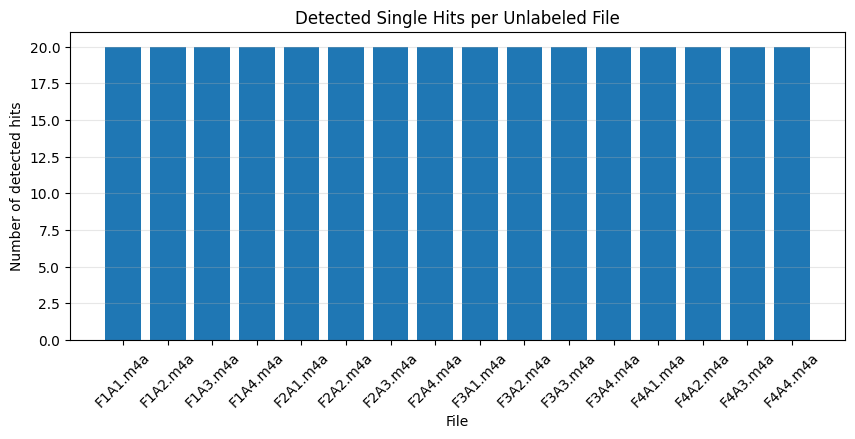

In [ ]:
hits_per_file = (
    unlabeled_hits_summary_df
    .groupby(["flange_id", "area_id", "file_name"])
    .size()
    .reset_index(name="number_of_hits")
)

display(hits_per_file)

plt.figure(figsize=(10, 4))
plt.bar(hits_per_file["file_name"], hits_per_file["number_of_hits"])
plt.title("Detected Single Hits per Unlabeled File")
plt.xlabel("File")
plt.ylabel("Number of detected hits")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Extract features for LR and SVM

In [ ]:
X_unlabeled_features = []

for item in unlabeled_hits:
    features = extract_hybrid_features(item["signal"], item["sr"])
    X_unlabeled_features.append(features)

X_unlabeled_features = np.array(X_unlabeled_features)

# Use the same scaler that was fitted on the training data
X_unlabeled_scaled = scaler.transform(X_unlabeled_features)

print("Unlabeled feature shape:", X_unlabeled_features.shape)
print("Scaled unlabeled feature shape:", X_unlabeled_scaled.shape)

Unlabeled feature shape: (320, 154)
Scaled unlabeled feature shape: (320, 154)


## Extract MFCC matrices for CNN and RNN

In [ ]:
X_unlabeled_mfcc = []

for item in unlabeled_hits:
    feature_stack = extract_mfcc_delta_stack(item["signal"], item["sr"])
    X_unlabeled_mfcc.append(feature_stack)

X_unlabeled_mfcc = np.array(X_unlabeled_mfcc)

# Normalize using the same mean and std from CNN/RNN training data
X_unlabeled_mfcc_norm = (X_unlabeled_mfcc - mfcc_mean) / (mfcc_std + 1e-8)

# CNN input is already 4D with 3 channels
X_unlabeled_cnn = X_unlabeled_mfcc_norm

# RNN input:
# Current shape: (samples, 20, 32, 3)
# Convert to:    (samples, 32, 60)
X_unlabeled_rnn = np.transpose(X_unlabeled_mfcc_norm, (0, 2, 1, 3))

X_unlabeled_rnn = X_unlabeled_rnn.reshape(
    X_unlabeled_rnn.shape[0],
    X_unlabeled_rnn.shape[1],
    X_unlabeled_rnn.shape[2] * X_unlabeled_rnn.shape[3]
)

print("Unlabeled MFCC stack shape:", X_unlabeled_mfcc.shape)
print("Unlabeled CNN shape:       ", X_unlabeled_cnn.shape)
print("Unlabeled RNN shape:       ", X_unlabeled_rnn.shape)

Unlabeled MFCC stack shape: (320, 20, 32, 3)
Unlabeled CNN shape:        (320, 20, 32, 3)
Unlabeled RNN shape:        (320, 32, 60)


## Predict torque for every single hit

In [ ]:
# Classical model predictions
pred_lr = log_reg_model.predict(X_unlabeled_scaled)
pred_svm = svm_model.predict(X_unlabeled_scaled)

# Deep learning predictions
pred_cnn_encoded = np.argmax(cnn_model.predict(X_unlabeled_cnn), axis=1)
pred_rnn_encoded = np.argmax(rnn_model.predict(X_unlabeled_rnn), axis=1)

# Convert CNN/RNN encoded labels back to torque values
pred_cnn = np.array([index_to_label[i] for i in pred_cnn_encoded])
pred_rnn = np.array([index_to_label[i] for i in pred_rnn_encoded])

# Store all hit-level predictions
unlabeled_predictions_df = pd.DataFrame({
    "file_name": [item["file_name"] for item in unlabeled_hits],
    "flange_id": [item["flange_id"] for item in unlabeled_hits],
    "area_id": [item["area_id"] for item in unlabeled_hits],
    "hit_id": [item["hit_id"] for item in unlabeled_hits],
    "LR_prediction": pred_lr,
    "SVM_prediction": pred_svm,
    "CNN_prediction": pred_cnn,
    "RNN_prediction": pred_rnn
})

display(unlabeled_predictions_df.head(20))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


,file_name,flange_id,area_id,hit_id,LR_prediction,SVM_prediction,CNN_prediction,RNN_prediction
0,F1A1.m4a,1,1,1,25,25,0,25
1,F1A1.m4a,1,1,2,0,25,0,25
2,F1A1.m4a,1,1,3,0,25,0,25
3,F1A1.m4a,1,1,4,25,25,0,25
4,F1A1.m4a,1,1,5,0,25,0,25
5,F1A1.m4a,1,1,6,0,25,50,50
6,F1A1.m4a,1,1,7,50,50,0,25
7,F1A1.m4a,1,1,8,0,25,0,25
8,F1A1.m4a,1,1,9,0,25,0,25
9,F1A1.m4a,1,1,10,0,25,0,25


In [ ]:
# Majority vote by file
# ============================================================
# Each file has several detected hits.
# We predict each hit, then take the most common predicted torque
# as the file-level prediction.

def majority_vote(series):
    """
    Return the most frequent prediction.
    If there is a tie, pandas returns one of the tied values consistently.
    """
    return series.value_counts().idxmax()


file_level_predictions = (
    unlabeled_predictions_df
    .groupby(["flange_id", "area_id", "file_name"])
    .agg({
        "LR_prediction": majority_vote,
        "SVM_prediction": majority_vote,
        "CNN_prediction": majority_vote,
        "RNN_prediction": majority_vote
    })
    .reset_index()
)

display(file_level_predictions)

,flange_id,area_id,file_name,LR_prediction,SVM_prediction,CNN_prediction,RNN_prediction
0,1,1,F1A1.m4a,0,25,0,25
1,1,2,F1A2.m4a,25,25,50,25
2,1,3,F1A3.m4a,0,25,0,0
3,1,4,F1A4.m4a,25,50,50,25
4,2,1,F2A1.m4a,0,0,0,0
5,2,2,F2A2.m4a,0,0,0,0
6,2,3,F2A3.m4a,0,0,0,0
7,2,4,F2A4.m4a,50,0,0,0
8,3,1,F3A1.m4a,50,50,0,0
9,3,2,F3A2.m4a,50,50,0,0


## Aggregate predictions by flange

In [ ]:
flange_level_predictions = (
    unlabeled_predictions_df
    .groupby("flange_id")
    .agg({
        "LR_prediction": majority_vote,
        "SVM_prediction": majority_vote,
        "CNN_prediction": majority_vote,
        "RNN_prediction": majority_vote
    })
    .reset_index()
)

flange_level_predictions["Flange"] = "Flange " + flange_level_predictions["flange_id"].astype(str)

flange_level_predictions = flange_level_predictions[
    ["Flange", "LR_prediction", "SVM_prediction", "CNN_prediction", "RNN_prediction"]
]

display(flange_level_predictions)

,Flange,LR_prediction,SVM_prediction,CNN_prediction,RNN_prediction
0,Flange 1,25,25,0,25
1,Flange 2,0,0,0,0
2,Flange 3,50,50,0,0
3,Flange 4,50,50,25,25


## Final decision using all models

In [ ]:
model_accuracies = {
    "LR_prediction": acc_lr,
    "SVM_prediction": acc_svm,
    "CNN_prediction": cnn_test_acc,
    "RNN_prediction": rnn_test_acc
}

# Models ranked from best to worst based on their test accuracy
model_priority = sorted(
    model_accuracies,
    key=model_accuracies.get,
    reverse=True
)

print("Tie-break priority:")
for model_name in model_priority:
    print(f"{model_name}: {model_accuracies[model_name] * 100:.2f}%")


def final_model_vote(row):
    """
    Combine the four predictions into one final prediction.
    """

    prediction_columns = [
        "LR_prediction",
        "SVM_prediction",
        "CNN_prediction",
        "RNN_prediction"
    ]

    # Store the votes with the model names
    votes = pd.Series({
        model_name: row[model_name]
        for model_name in prediction_columns
    })

    # Count how many times each torque value was predicted
    vote_counts = votes.value_counts()
    max_votes = vote_counts.max()

    # Find the torque values with the highest vote count
    top_classes = vote_counts[vote_counts == max_votes].index.tolist()

    # If there is only one winner, return it directly
    if len(top_classes) == 1:
        return top_classes[0]

    # If there is a tie, use the best model as the tie-breaker
    for model_name in model_priority:
        if row[model_name] in top_classes:
            return row[model_name]


def decision_reason(row):
    """
    Explain how the final prediction was chosen.
    """

    prediction_columns = [
        "LR_prediction",
        "SVM_prediction",
        "CNN_prediction",
        "RNN_prediction"
    ]

    votes = pd.Series([row[col] for col in prediction_columns])
    vote_counts = votes.value_counts()
    max_votes = vote_counts.max()
    top_classes = vote_counts[vote_counts == max_votes].index.tolist()

    if len(top_classes) == 1:
        return f"Majority vote for {top_classes[0]} ft-lbs"

    for model_name in model_priority:
        if row[model_name] in top_classes:
            clean_name = model_name.replace("_prediction", "")
            return f"Tie between {top_classes}; used {clean_name} as tie-breaker"


final_results_df = flange_level_predictions.copy()

final_results_df["Final_prediction"] = final_results_df.apply(
    final_model_vote,
    axis=1
)

final_results_df["Decision_reason"] = final_results_df.apply(
    decision_reason,
    axis=1
)

display(final_results_df)

Tie-break priority:
SVM_prediction: 100.00%
LR_prediction: 99.66%
CNN_prediction: 99.66%
RNN_prediction: 95.96%


,Flange,LR_prediction,SVM_prediction,CNN_prediction,RNN_prediction,Final_prediction,Decision_reason
0,Flange 1,25,25,0,25,25,Majority vote for 25 ft-lbs
1,Flange 2,0,0,0,0,0,Majority vote for 0 ft-lbs
2,Flange 3,50,50,0,0,50,"Tie between [50, 0]; used SVM as tie-breaker"
3,Flange 4,50,50,25,25,50,"Tie between [50, 25]; used SVM as tie-breaker"


## Format final competition table

In [ ]:
competition_table = pd.DataFrame({
    "Flange 1": [
        str(final_results_df.loc[final_results_df["Flange"] == "Flange 1", "Final_prediction"].values[0]) + " ft-lbs"
    ],
    "Flange 2": [
        str(final_results_df.loc[final_results_df["Flange"] == "Flange 2", "Final_prediction"].values[0]) + " ft-lbs"
    ],
    "Flange 3": [
        str(final_results_df.loc[final_results_df["Flange"] == "Flange 3", "Final_prediction"].values[0]) + " ft-lbs"
    ],
    "Flange 4": [
        str(final_results_df.loc[final_results_df["Flange"] == "Flange 4", "Final_prediction"].values[0]) + " ft-lbs"
    ]
}, index=["Classification result"])

display(competition_table)